In [110]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)


currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path


In [111]:
np.floor(5*0.1)

np.float64(0.0)

# Load Feature Matrix & Initial Inspection

In [126]:
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\raw-breathmetrics-features-session-2sec-subjectnames")
feature_matrix.columns

Index(['WindowID', 'Start', 'Stop', 'Duration', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_breathing_rate', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol', 'cv_tidal_vol', 'minute_ventilation', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'Trial', 'Subject', 'Recording', 'MouseSubject', 'Condition', 'Rank', 'Type', 'session_duration_sec', 'n_breaths_total', 'WindowSec', 'n_bouts_anogenital_sniffing', 'n_bouts_body_sniffing', 'n_bouts_facial_sniffing', 'total_dur_anogenital_sniffing', 'total_dur_body_sniffing', 'total_dur_facial_sniffing'], dtype='object')

In [127]:
print(feature_matrix["Condition"].value_counts())

Condition
RI1     794
RI2     760
BLRI    696
Name: count, dtype: int64


In [128]:
feature_matrix

,WindowID,Start,Stop,Duration,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_breathing_rate,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol,cv_tidal_vol,minute_ventilation,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle,Trial,Subject,Recording,MouseSubject,Condition,Rank,Type,session_duration_sec,n_breaths_total,WindowSec,n_bouts_anogenital_sniffing,n_bouts_body_sniffing,n_bouts_facial_sniffing,total_dur_anogenital_sniffing,total_dur_body_sniffing,total_dur_facial_sniffing
0,0,22.0,24.0,2.0,21,10.230179,0.097750,0.119386,0.040238,0.159159,0.056310,0.389133,0.714588,1097.355393,-1038.295346,0.314565,31851.248621,40006.925144,71858.173765,0.420068,735121.982251,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.411643,0.576057,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
1,1,28.0,30.0,2.0,19,9.523810,0.105000,0.194566,0.042632,0.131091,0.056842,0.366546,0.750000,1108.195915,-948.141837,0.268143,33478.067004,36736.123472,70214.190475,0.357817,668706.575956,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.406015,0.541353,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
2,2,32.0,34.0,2.0,20,9.620253,0.103947,0.114765,0.043875,0.131764,0.055750,0.179988,0.786996,1149.622486,-1000.130706,0.215808,35579.550606,37648.419147,73227.969754,0.334772,704471.607757,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.422089,0.536329,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
3,3,34.0,36.0,2.0,18,9.497207,0.105294,0.102328,0.043750,0.201806,0.057361,0.185179,0.762712,1228.694587,-1056.541695,0.342465,39298.885158,40813.159328,80112.044486,0.501146,760840.645955,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.415503,0.544770,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
4,4,38.0,40.0,2.0,18,9.418283,0.106176,0.103776,0.048056,0.123299,0.058472,0.404896,0.821853,1387.929677,-969.699373,0.247949,46352.905907,39194.096385,85547.002292,0.338973,805705.838759,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.452601,0.550708,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,95,580.0,582.0,2.0,14,7.471264,0.133846,0.366061,0.056250,0.249019,0.070179,0.448884,0.801527,1499.122381,-1153.028824,0.283875,56252.210481,52014.052996,108266.263477,0.389755,808885.876551,0.071429,0.0700,0.0,0.037356,0.142857,0.17375,0.741007,0.185447,0.420259,0.524323,BLRI_4_8,4_8,BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5,4_8,BLRI,Dominant,Baseline,605.0125,4351,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2246,96,582.0,584.0,2.0,13,7.350689,0.136042,0.408061,0.060000,0.550592,0.064231,0.276229,0.934132,1684.503331,-1283.044015,0.316067,65719.801052,56729.421495,122449.222547,0.448557,900086.168798,0.076923,0.0375,0.0,0.021204,0.000000,0.00000,NaN,0.000000,0.441041,0.472140,BLRI_4_8,4_8,BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5,4_8,BLRI,Dominant,Baseline,605.0125,4351,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2247,97,584.0,586.0,2.0,14,6.565657,0.152308,0.563494,0.050000,0.197303,0.066964,0.328563,0.746667,1490.954994,-1153.878714,0.302178,49365.513367,50372.056187,99737.569554,0.375873,654842.628386,0.0000

In [115]:
feature_matrix.columns

Index(['WindowID', 'Start', 'Stop', 'Duration', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_breathing_rate', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol', 'cv_tidal_vol', 'minute_ventilation', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'Trial', 'Subject', 'Condition', 'Rank', 'Type', 'session_duration_sec', 'n_breaths_total', 'WindowSec', 'n_bouts_anogenital_sniffing', 'n_bouts_body_sniffing', 'n_bouts_facial_sniffing', 'total_dur_anogenital_sniffing', 'total_dur_body_sniffing', 'total_dur_facial_sniffing'], dtype='object')

# Define Target Classes & Extract Feature Matrix

In [116]:
# Keep only target classes of interest
TARGET_COL = "Condition"
TARGET_CLASSES = ["RI1", "RI2"]

df = feature_matrix.copy()
df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)

# -------------------------------------------------------------------
# TrueMouseID: one biological mouse across RI1 and RI2 (correct LOSO unit).
# Trial is often RI1_1_1 / RI2_1_1; older pickles may lack MouseSubject but still have Trial.
# MouseSubject from extraction can be the filename pair (e.g. 1_1) without an RI prefix.
# -------------------------------------------------------------------
def _strip_ri12_prefix(s: pd.Series) -> pd.Series:
    return s.astype(str).str.replace(r"^RI[12]_", "", regex=True)


true_id = None
if "Trial" in df.columns:
    t = df["Trial"].astype(str)
    if t.str.match(r"^RI[12]_", na=False).any():
        true_id = _strip_ri12_prefix(t)
if true_id is None and "MouseSubject" in df.columns:
    m = df["MouseSubject"].astype(str)
    true_id = (
        _strip_ri12_prefix(m)
        if m.str.match(r"^RI[12]_", na=False).any()
        else m
    )
if true_id is None and "Subject" in df.columns:
    true_id = df["Subject"].astype(str)

if true_id is None:
    raise ValueError(
        "Could not build TrueMouseID: need 'Trial' (RI1_/RI2_…), "
        "'MouseSubject', or 'Subject' on the feature matrix."
    )

df["TrueMouseID"] = true_id

group_summary = (
    df.groupby("TrueMouseID", observed=True)[TARGET_COL]
    .value_counts()
    .unstack(fill_value=0)
    .sort_index()
)
print("=" * 80)
print("Per-true-mouse class balance (windows)")
print("=" * 80)
display(group_summary)
print("n unique TrueMouseID:", df["TrueMouseID"].nunique())

# Keep only true mice that contain both RI1 and RI2
n_cls_per_mouse = df.groupby("TrueMouseID", observed=True)[TARGET_COL].nunique()
valid_mice = n_cls_per_mouse[n_cls_per_mouse > 1].index
excluded_mice = sorted(set(df["TrueMouseID"].unique()) - set(valid_mice))

if excluded_mice:
    print(
        f"Excluding {len(excluded_mice)} true mouse ID(s) with only one target class: "
        f"{excluded_mice}"
    )

df = df[df["TrueMouseID"].isin(valid_mice)].reset_index(drop=True)

if len(df) == 0:
    raise ValueError("No rows left after excluding single-class true mice.")

# Explicit metadata + non-feature columns to exclude
EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Recording",
    "MouseSubject",
    "TrueMouseID",
    "Rank",
    "Type",
    "Label",
    "WindowID",
    "WindowSec",
    "session_duration_sec",
    "n_breaths_total",
}

if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

# Keep only numeric respiration features (drop any BORIS/behavior summary columns)
BEHAVIOR_COL_PREFIXES = (
    "n_bouts_",
    "total_dur_",
)

candidate_feature_cols = [
    c
    for c in df.columns
    if (
        c not in EXCLUDE_FROM_FEATURES
        and pd.api.types.is_numeric_dtype(df[c])
        and not str(c).startswith(BEHAVIOR_COL_PREFIXES)
    )
]

X_all = df[candidate_feature_cols].copy()
y = df[TARGET_COL].copy()

groups = df["TrueMouseID"].copy()
GROUP_KEY_FOR_CV = "TrueMouseID"

Per-true-mouse class balance (windows)


Condition,RI1,RI2
TrueMouseID,,
1_1,100,100
1_2,95,95
2_3,100,96
2_4,100,82
3_5,100,100
3_6,100,87
4_7,100,100
4_8,99,100


n unique TrueMouseID: 8


# Model Setup: Grouped Cross-Validation, Feature Selection, and Baseline Model Definitions

In [117]:
# Inner model-selection CV: stratified by class, grouped so the same TrueMouseID
# never appears in both train and validation folds.
if groups is not None and groups.nunique() >= 3:
    n_splits = min(5, groups.nunique())
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    gname = GROUP_KEY_FOR_CV or "group"
    cv_mode = (
        f"StratifiedGroupKFold(n_splits={n_splits}, shuffle=True, random_state=42) "
        f"[group={gname}]"
    )
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Drop feature columns with too many missing values
MAX_MISSING_FRAC = 0.40
missing_frac = X_all.isna().mean(axis=0)
kept_feature_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
dropped_feature_cols = missing_frac[missing_frac > MAX_MISSING_FRAC].sort_values(ascending=False)

X = X_all[kept_feature_cols].copy()

# Preprocessing pipeline with imputation + scaling (for linear models and SVM)
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing pipeline with imputation only (for tree-based models)
preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# End-to-end model pipelines (safe against leakage when used in grouped CV)
logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

print(f"Rows retained after target filter: {len(df)}")
print(f"Target class counts:\n{y.value_counts(dropna=False)}\n")
print(f"Candidate numeric resp features: {len(candidate_feature_cols)}")
print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {X.shape[1]}")
print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(dropped_feature_cols)}")
if len(dropped_feature_cols):
    print("Dropped columns and missing fraction:")
    display(dropped_feature_cols.to_frame(name="missing_fraction"))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"groups available: {groups is not None}")
print(f"CV strategy (for GridSearch / learning curves): {cv_mode}")

# --- Shared leave-one-mouse-out evaluation (following cells call this) ---
from sklearn.base import clone
from sklearn.metrics import f1_score, classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.utils.class_weight import compute_sample_weight

classes = np.sort(y.unique())


def _recording_level_from_windows(y_true_arr, y_pred_arr, recordings, label_classes):
    'One valence label per recording via majority vote over its windows.'
    d = pd.DataFrame(
        {"Recording": recordings, "y_true": y_true_arr, "y_pred": y_pred_arr}
    )

    def _mode(s):
        m = s.mode()
        return m.iloc[0] if len(m) else np.nan

    yt = d.groupby("Recording", observed=True)["y_true"].agg(_mode)
    yp = d.groupby("Recording", observed=True)["y_pred"].agg(_mode)
    common = yt.index.intersection(yp.index)
    yt = yt.loc[common]
    yp = yp.loc[common]
    if len(common) == 0:
        return np.nan, np.nan
    ba = balanced_accuracy_score(yt, yp)
    f1 = f1_score(yt, yp, labels=label_classes, average="macro", zero_division=0)
    return ba, f1


def evaluate_mouse_loso(base_model, model_name, shuffle_labels=False):
    # Leave-one-mouse-out on windows; recording-level majority vote as secondary metric.
    if groups is None or groups.nunique() < 2:
        raise ValueError("Need at least 2 mice (group IDs) for leave-one-mouse-out.")

    y_eval = y.copy()
    if shuffle_labels:
        rng = np.random.RandomState(42)
        y_eval = pd.Series(rng.permutation(y_eval.values), index=y_eval.index)

    loo = LeaveOneGroupOut()
    bal_m, f1_m = [], []
    bal_r, f1_r = [], []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(
        loo.split(X, y_eval, groups=groups), start=1
    ):
        held_mouse = groups.iloc[test_idx].iloc[0]
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_eval.iloc[train_idx], y_eval.iloc[test_idx]

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)
        y_pred = model.predict(X_test)

        ba = balanced_accuracy_score(y_test, y_pred)
        mf1 = f1_score(
            y_test, y_pred, labels=classes, average="macro", zero_division=0
        )

        # Flip-check for possible RI1/RI2 inversion in a held-out mouse.
        y_pred_flipped = np.where(np.asarray(y_pred) == "RI1", "RI2", "RI1")
        ba_flip = balanced_accuracy_score(y_test, y_pred_flipped)
        mf1_flip = f1_score(
            y_test, y_pred_flipped, labels=classes, average="macro", zero_division=0
        )

        bal_m.append(ba)
        f1_m.append(mf1)

        if "Recording" in df.columns:
            rec_col = df.iloc[test_idx]["Recording"].values
            bar, f1rec = _recording_level_from_windows(
                y_test.values, y_pred, rec_col, classes
            )
        else:
            bar, f1rec = np.nan, np.nan
        bal_r.append(bar)
        f1_r.append(f1rec)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(
            f"[{model_name}] held-out mouse={held_mouse} (fold {fold_idx}): "
            f"window bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"recording bal_acc={bar:.3f}, macro_f1={f1rec:.3f}"
        )
        print(
            f"    flip-check: original bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"flipped bal_acc={ba_flip:.3f}, macro_f1={mf1_flip:.3f}"
        )

    bal_m = np.asarray(bal_m, dtype=float)
    f1_m = np.asarray(f1_m, dtype=float)
    bal_r = np.asarray(bal_r, dtype=float)
    f1_r = np.asarray(f1_r, dtype=float)

    tag = "  [label shuffle]" if shuffle_labels else ""
    print(f"\n[{model_name}] Mouse-level (held-out windows) - mean +/- std over mice{tag}:")
    print(f"  balanced accuracy: {bal_m.mean():.3f} +/- {bal_m.std():.3f}  (n={len(bal_m)} mice)")
    print(f"  macro F1:          {f1_m.mean():.3f} +/- {f1_m.std():.3f}")
    print(f"\n[{model_name}] Recording-level (majority vote over windows){tag}:")
    print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
    print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")

    if not shuffle_labels:
        print(f"\n[{model_name}] Pooled window-level OOF report:")
        print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))
        cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in classes],
            columns=[f"pred_{c}" for c in classes],
        )
        display(cm_df)


Rows retained after target filter: 1554
Target class counts:
Condition
RI1    794
RI2    760
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.911197
cv_exhale_pause_dur,0.584299


X shape: (1554, 25)
y shape: (1554,)
groups available: True
CV strategy (for GridSearch / learning curves): StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42) [group=TrueMouseID]


# Primary Leave-One-Mouse-Out Evaluation and Leakage Check

In [118]:
if groups is None:
    raise ValueError(
        "No grouping column for LOSO. Expected TrueMouseID on df (see target-class cell)."
    )

print("=" * 80)
print("Per-TrueMouseID class balance (windows) - inspect before LOSO")
print("=" * 80)
_mouse_bal = (
    df.assign(_mouse_group=groups.values)
    .groupby("_mouse_group", observed=True)[TARGET_COL]
    .value_counts()
    .unstack(fill_value=0)
)
display(_mouse_bal.sort_index())
print(f"\nUnique TrueMouseID (grouping variable): {groups.nunique()}")

print("\n" + "=" * 80)
print("Primary evaluation: Leave-One-Mouse-Out (LOMO / LOSO)")
print("Question: Do respiration features generalize valence to a new mouse?")
print("=" * 80 + "\n")

evaluate_mouse_loso(logreg_clf, "LogisticRegression", shuffle_labels=False)
print("\n" + "=" * 80 + "\n")
evaluate_mouse_loso(svm_clf, "SVM", shuffle_labels=False)
print("\n" + "=" * 80 + "\n")
evaluate_mouse_loso(rf_clf, "RandomForest", shuffle_labels=False)

print("\n" + "=" * 80)
print("Label-shuffle sanity check (LogisticRegression). High score => possible leakage.")
print("=" * 80 + "\n")
evaluate_mouse_loso(logreg_clf, "LogisticRegression_shuffled_y", shuffle_labels=True)


Per-TrueMouseID class balance (windows) - inspect before LOSO


Condition,RI1,RI2
_mouse_group,,
1_1,100,100
1_2,95,95
2_3,100,96
2_4,100,82
3_5,100,100
3_6,100,87
4_7,100,100
4_8,99,100



Unique TrueMouseID (grouping variable): 8

Primary evaluation: Leave-One-Mouse-Out (LOMO / LOSO)
Question: Do respiration features generalize valence to a new mouse?

[LogisticRegression] held-out mouse=1_1 (fold 1): window bal_acc=0.810, macro_f1=0.810 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.810, macro_f1=0.810 | flipped bal_acc=0.190, macro_f1=0.190
[LogisticRegression] held-out mouse=1_2 (fold 2): window bal_acc=0.695, macro_f1=0.695 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.695, macro_f1=0.695 | flipped bal_acc=0.305, macro_f1=0.305
[LogisticRegression] held-out mouse=2_3 (fold 3): window bal_acc=0.732, macro_f1=0.728 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.732, macro_f1=0.728 | flipped bal_acc=0.268, macro_f1=0.252
[LogisticRegression] held-out mouse=2_4 (fold 4): window bal_acc=0.877, macro_f1=0.882 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.877, macro_f

C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:176: RuntimeWarning: Mean of empty slice
  print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:177: RuntimeWarning: Mean of empty slice
  print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")


,pred_RI1,pred_RI2
true_RI1,678,116
true_RI2,192,568


...



[RandomForest] held-out mouse=1_1 (fold 1): window bal_acc=0.795, macro_f1=0.795 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.795, macro_f1=0.795 | flipped bal_acc=0.205, macro_f1=0.205
[RandomForest] held-out mouse=1_2 (fold 2): window bal_acc=0.705, macro_f1=0.703 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.705, macro_f1=0.703 | flipped bal_acc=0.295, macro_f1=0.288
[RandomForest] held-out mouse=2_3 (fold 3): window bal_acc=0.726, macro_f1=0.720 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.726, macro_f1=0.720 | flipped bal_acc=0.274, macro_f1=0.249
[RandomForest] held-out mouse=2_4 (fold 4): window bal_acc=0.856, macro_f1=0.862 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.856, macro_f1=0.862 | flipped bal_acc=0.144, macro_f1=0.121
[RandomForest] held-out mouse=3_5 (fold 5): window bal_acc=0.770, macro_f1=0.769 | recording bal_acc=nan, macro_f1=nan
    flip-check: origina

C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:176: RuntimeWarning: Mean of empty slice
  print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:177: RuntimeWarning: Mean of empty slice
  print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")


,pred_RI1,pred_RI2
true_RI1,691,103
true_RI2,224,536



Label-shuffle sanity check (LogisticRegression). High score => possible leakage.

[LogisticRegression_shuffled_y] held-out mouse=1_1 (fold 1): window bal_acc=0.461, macro_f1=0.460 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.461, macro_f1=0.460 | flipped bal_acc=0.539, macro_f1=0.539
[LogisticRegression_shuffled_y] held-out mouse=1_2 (fold 2): window bal_acc=0.485, macro_f1=0.484 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.485, macro_f1=0.484 | flipped bal_acc=0.515, macro_f1=0.515
[LogisticRegression_shuffled_y] held-out mouse=2_3 (fold 3): window bal_acc=0.488, macro_f1=0.487 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.488, macro_f1=0.487 | flipped bal_acc=0.512, macro_f1=0.510
[LogisticRegression_shuffled_y] held-out mouse=2_4 (fold 4): window bal_acc=0.473, macro_f1=0.462 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.473, macro_f1=0.462 | flipped bal_acc=0.527, macro_f1

C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:176: RuntimeWarning: Mean of empty slice
  print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:177: RuntimeWarning: Mean of empty slice
  print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")


# Regularized Model Evaluation and Learning Curve Analysis

Learning-curve CV: StratifiedGroupKFold(n_splits=5, shuffle=True) [mouse-level groups]
Regularized models - same LOMO protocol as previous cell


  LogisticRegression_L2

[LogisticRegression_L2] held-out mouse=1_1 (fold 1): window bal_acc=0.830, macro_f1=0.830 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.830, macro_f1=0.830 | flipped bal_acc=0.170, macro_f1=0.170
[LogisticRegression_L2] held-out mouse=1_2 (fold 2): window bal_acc=0.700, macro_f1=0.699 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.700, macro_f1=0.699 | flipped bal_acc=0.300, macro_f1=0.298
[LogisticRegression_L2] held-out mouse=2_3 (fold 3): window bal_acc=0.716, macro_f1=0.712 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.716, macro_f1=0.712 | flipped bal_acc=0.284, macro_f1=0.267
[LogisticRegression_L2] held-out mouse=2_4 (fold 4): window bal_acc=0.865, macro_f1=0.870 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc

C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:176: RuntimeWarning: Mean of empty slice
  print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:177: RuntimeWarning: Mean of empty slice
  print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")


,pred_RI1,pred_RI2
true_RI1,677,117
true_RI2,203,557


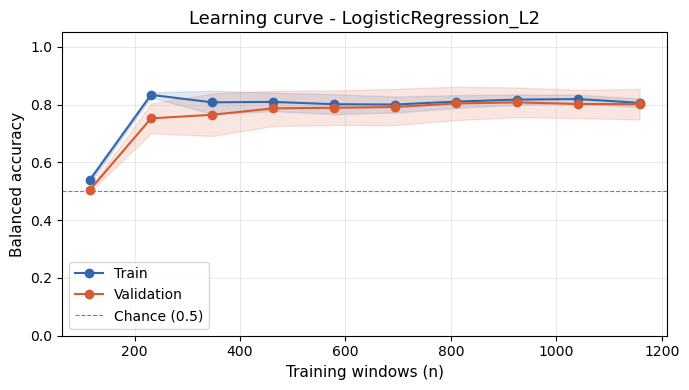

[LogisticRegression_L2] Validation curve verdict: flattened - data volume looks sufficient for this model


  SVM_regularized

[SVM_regularized] held-out mouse=1_1 (fold 1): window bal_acc=0.815, macro_f1=0.814 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.815, macro_f1=0.814 | flipped bal_acc=0.185, macro_f1=0.183
[SVM_regularized] held-out mouse=1_2 (fold 2): window bal_acc=0.726, macro_f1=0.717 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.726, macro_f1=0.717 | flipped bal_acc=0.274, macro_f1=0.250
[SVM_regularized] held-out mouse=2_3 (fold 3): window bal_acc=0.680, macro_f1=0.674 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.680, macro_f1=0.674 | flipped bal_acc=0.320, macro_f1=0.300
[SVM_regularized] held-out mouse=2_4 (fold 4): window bal_acc=0.793, macro_f1=0.797 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.793, macro_f1=0.797 | flipped bal_acc=0.207, macro_f1=0.157
[SVM_

C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:176: RuntimeWarning: Mean of empty slice
  print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:177: RuntimeWarning: Mean of empty slice
  print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")


,pred_RI1,pred_RI2
true_RI1,721,73
true_RI2,284,476


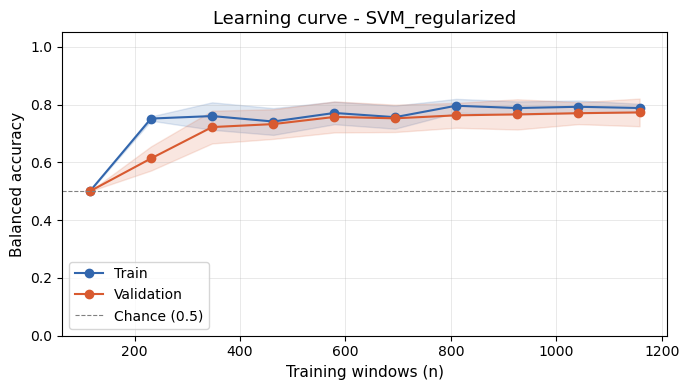

[SVM_regularized] Validation curve verdict: flattened - data volume looks sufficient for this model


  RandomForest_regularized

[RandomForest_regularized] held-out mouse=1_1 (fold 1): window bal_acc=0.785, macro_f1=0.785 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.785, macro_f1=0.785 | flipped bal_acc=0.215, macro_f1=0.215
[RandomForest_regularized] held-out mouse=1_2 (fold 2): window bal_acc=0.705, macro_f1=0.701 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.705, macro_f1=0.701 | flipped bal_acc=0.295, macro_f1=0.285
[RandomForest_regularized] held-out mouse=2_3 (fold 3): window bal_acc=0.700, macro_f1=0.691 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.700, macro_f1=0.691 | flipped bal_acc=0.300, macro_f1=0.271
[RandomForest_regularized] held-out mouse=2_4 (fold 4): window bal_acc=0.841, macro_f1=0.848 | recording bal_acc=nan, macro_f1=nan
    flip-check: original bal_acc=0.841, macro_f1=0.848 | flip

C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:176: RuntimeWarning: Mean of empty slice
  print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\thoma\AppData\Local\Temp\ipykernel_13900\202766572.py:177: RuntimeWarning: Mean of empty slice
  print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")


,pred_RI1,pred_RI2
true_RI1,706,88
true_RI2,252,508


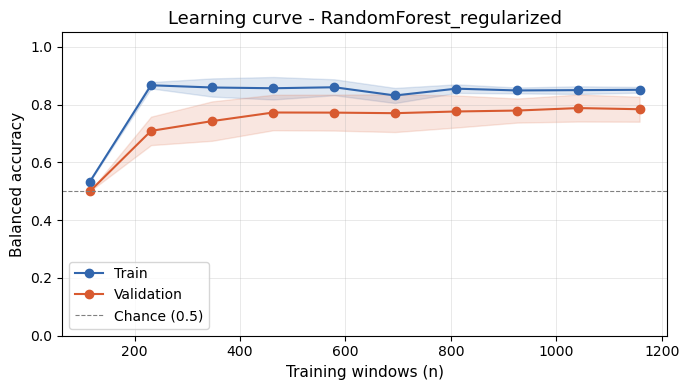

[RandomForest_regularized] Validation curve verdict: flattened - data volume looks sufficient for this model



In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, learning_curve

# Explicitly regularized models (separate pipelines from the default cell above)

preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        penalty="l2",
        C=0.1,
        class_weight=None,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(
        kernel="rbf",
        C=0.1,
        gamma="scale",
        class_weight=None,
        random_state=42
    ))
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        bootstrap=True,
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Learning curves use grouped CV by mouse (same as GridSearch inner CV)
if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_lc = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_lc_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True) [mouse-level groups]"
else:
    n_splits_eval = 5
    cv_lc = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_lc_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

print(f"Learning-curve CV: {cv_lc_mode}")
print("Regularized models - same LOMO protocol as previous cell\n")


def plot_learning_curve(base_model, model_name, train_sizes=np.linspace(0.1, 1.0, 10)):
    lc_kwargs = dict(
        estimator=base_model,
        X=X,
        y=y,
        cv=cv_lc,
        scoring="balanced_accuracy",
        train_sizes=train_sizes,
        n_jobs=-1,
        return_times=False,
    )
    if groups is not None and pd.Series(groups).nunique() >= 3:
        lc_kwargs["groups"] = groups

    train_sizes_abs, train_scores, val_scores = learning_curve(**lc_kwargs)

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_sizes_abs, train_mean, "o-", color="#3266ad", label="Train")
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3266ad")
    ax.plot(train_sizes_abs, val_mean, "o-", color="#d85a30", label="Validation")
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#d85a30")

    ax.set_title(f"Learning curve - {model_name}", fontsize=13)
    ax.set_xlabel("Training windows (n)", fontsize=11)
    ax.set_ylabel("Balanced accuracy", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance (0.5)")
    ax.legend(fontsize=10)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

    val_slope = val_mean[-1] - val_mean[-3]
    if val_slope > 0.02:
        verdict = "still rising - consider collecting more windows"
    elif val_mean[-1] < 0.55:
        verdict = "flat but low - model may need different features, not more data"
    else:
        verdict = "flattened - data volume looks sufficient for this model"
    print(f"[{model_name}] Validation curve verdict: {verdict}\n")


for model, name in [(logreg_clf, "LogisticRegression_L2"),
                    (svm_clf, "SVM_regularized"),
                    (rf_clf, "RandomForest_regularized")]:

    print(f"\n{'='*80}")
    print(f"  {name}")
    print(f"{'='*80}\n")

    evaluate_mouse_loso(model, name, shuffle_labels=False)
    print()
    plot_learning_curve(model, name)


In [120]:
# NaN audit + drop columns/rows with excessive missingness
COL_NAN_THRESHOLD = 0.40
ROW_NAN_THRESHOLD = 0.40

nan_by_col = feature_matrix.isna().sum().sort_values(ascending=False)
nan_by_row = feature_matrix.isna().sum(axis=1)

total_nans = int(nan_by_col.sum())
col_nan_frac = feature_matrix.isna().mean(axis=0)
row_nan_frac = feature_matrix.isna().mean(axis=1)

cols_to_drop = col_nan_frac[col_nan_frac > COL_NAN_THRESHOLD].index.tolist()
rows_to_drop = row_nan_frac[row_nan_frac > ROW_NAN_THRESHOLD].index.tolist()

feature_matrix_clean = (
    feature_matrix
    .drop(columns=cols_to_drop)
    .drop(index=rows_to_drop)
    .reset_index(drop=True)
)

print(f"Total NaNs in feature_matrix: {total_nans}")
print(f"Columns with >=1 NaN: {(nan_by_col > 0).sum()} / {feature_matrix.shape[1]}")
print(f"Rows with >=1 NaN: {(nan_by_row > 0).sum()} / {feature_matrix.shape[0]}\n")

print(f"Columns dropped (> {COL_NAN_THRESHOLD:.0%} NaN): {len(cols_to_drop)}")
if cols_to_drop:
    display(col_nan_frac.loc[cols_to_drop].sort_values(ascending=False).to_frame("nan_fraction"))

print(f"Rows dropped (> {ROW_NAN_THRESHOLD:.0%} NaN): {len(rows_to_drop)}")
print(f"Original shape: {feature_matrix.shape}")
print(f"Cleaned shape: {feature_matrix_clean.shape}")

Total NaNs in feature_matrix: 9850
Columns with >=1 NaN: 8 / 45
Rows with >=1 NaN: 2204 / 2250

Columns dropped (> 40% NaN): 6


,nan_fraction
cv_inhale_pause_dur,0.912889
n_bouts_anogenital_sniffing,0.568000
total_dur_anogenital_sniffing,0.568000
cv_exhale_pause_dur,0.558222
n_bouts_body_sniffing,0.487111
total_dur_body_sniffing,0.487111


Rows dropped (> 40% NaN): 0
Original shape: (2250, 45)
Cleaned shape: (2250, 39)


In [121]:
df[df["TrueMouseID"] == "3_6"][candidate_feature_cols].describe()

,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_breathing_rate,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol,cv_tidal_vol,minute_ventilation,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle
count,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,1.870000e+02,187.000000,187.000000,18.000000,187.000000,187.000000,187.000000,82.000000,187.000000,187.000000,187.000000
mean,11.288770,5.906693,0.210983,0.358078,0.127549,0.410824,0.087480,0.377100,1.388287,1150.703447,-852.790466,0.309575,61853.103886,45620.239070,107473.342956,0.492865,5.976525e+05,0.013814,0.025515,0.020438,0.012494,0.083269,0.112765,0.200631,0.084792,0.546263,0.471495
std,4.545118,2.184052,0.145254,0.265145,0.219449,0.370161,0.028579,0.253729,1.978078,590.721410,310.028571,0.164146,44852.154633,19490.273186,51516.766536,0.289983,2.637033e+05,0.052999,0.257421,0.086709,0.117529,0.152333,0.207639,0.322148,0.159816,0.622172,0.114986
min,2.000000,0.798403,0.097750,0.000000,0.040238,0.023063,0.043875,0.000000,0.401152,339.846081,-1747.902693,0.011705,20582.139591,17948.291735,50618.357967,0.052339,8.445934e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.123188,0.051282
25%,8.000000,4.419890,0.131917,0.157501,0.055391,0.143511,0.066015,0.205784,0.746734,712.018449,-1027.557022,0.212148,39333.617038,32614.018663,77278.601668,0.316294,3.974392e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.384041,0.428627
50%,11.000000,5.866667,0.170455,0.299420,0.071923,0.305236,0.082708,0.344445,0.881313,1108.195915,-823.895107,0.296917,49409.534352,40505.093218,93142.425386,0.420348,5.812007e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.445424,0.498827
75%,15.000000,7.580692,0.226250,0.478861,0.099583,0.579439,0.101771,0.500368,1.110973,1390.071409,-640.366785,0.376748,62812.804693,54397.973292,116711.971840,0.575128,7.454863e+05,0.000000,0.000000,0.000000,0.000000,0.111111,0.157500,0.359512,0.098812,0.486953,0.536537
max,21.000000,10.230179,1.252500,1.232454,1.531250,2.113367,0.205625,1.549967,14.759036,5390.029925,-329.300353,1.111388,311872.469084,130054.907093,410039.197372,1.923566,1.439215e+06,0.500000,3.507500,0.367876,1.588542,1.000000,1.000000,1.133132,0.921360,5.103261,0.854545


# Hyperparameter Tuning with Grouped Cross-Validation

In [124]:
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.base import clone
from imblearn.ensemble import RUSBoostClassifier

# ---------------------------------------------------------------------
# Row-aligned feature matrix for nested search
# ---------------------------------------------------------------------
X_search = X.copy()
y_search = y.copy()
groups_search = groups.copy()

if groups_search is None or len(groups_search) != len(X_search):
    raise ValueError("Nested LOSO tuning requires a valid grouping vector aligned with X_search.")
classes = np.sort(y_search.unique())

# ---------------------------------------------------------------------
# Model grids
# ---------------------------------------------------------------------
search_scoring = "balanced_accuracy"

fast_models_and_grids = {
    "LogisticRegression": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs")),
        ]),
        {
            "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        },
    ),
    "SVM": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
        ]),
        {
            "model__C": [0.1, 1.0, 10.0, 100.0],
            "model__gamma": ["scale", 0.01, 0.1, 1.0],
        },
    ),
    "RandomForest": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
        ]),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_leaf": [1, 3, 5],
            "model__max_features": ["sqrt", 0.5],
        },
    ),
}

rusboost_entry = {
    "RUSBoost": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            (
                "model",
                RUSBoostClassifier(
                    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                    random_state=42,
                ),
            ),
        ]),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5, 1.0],
            "model__sampling_strategy": ["auto", "not minority", "all"],
            "model__replacement": [False, True],
            "model__estimator": [
                DecisionTreeClassifier(max_depth=1, random_state=42),
                DecisionTreeClassifier(max_depth=2, random_state=42),
            ],
        },
    ),
}

# Set to True only when you explicitly want the slow RUSBoost search.
RUN_RUSBOOST = False
models_and_grids = dict(fast_models_and_grids)
if RUN_RUSBOOST:
    models_and_grids.update(rusboost_entry)
else:
    print("Skipping RUSBoost in nested search (RUN_RUSBOOST=False).")

# ---------------------------------------------------------------------
# Nested LOSO evaluation
# ---------------------------------------------------------------------
outer_cv = LeaveOneGroupOut()
nested_results = {}

for model_name, (pipe, param_grid) in models_and_grids.items():
    print("\n" + "=" * 90)
    print(f"Nested LOSO tuning + evaluation: {model_name}")
    print("=" * 90)

    outer_bal_acc = []
    outer_macro_f1 = []
    y_true_all = []
    y_pred_all = []
    best_params_per_mouse = []

    for fold_idx, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_search, y_search, groups=groups_search), start=1
    ):
        held_out_mouse = groups_search.iloc[test_idx].iloc[0]

        X_train = X_search.iloc[train_idx]
        X_test = X_search.iloc[test_idx]
        y_train = y_search.iloc[train_idx]
        y_test = y_search.iloc[test_idx]
        groups_train = groups_search.iloc[train_idx]

        # Inner CV only on training mice
        n_train_groups = groups_train.nunique()
        if n_train_groups >= 3:
            inner_splits = min(5, n_train_groups)
            inner_cv = StratifiedGroupKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42,
            )
        else:
            inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=search_scoring,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )

        if isinstance(inner_cv, StratifiedGroupKFold):
            gs.fit(X_train, y_train, groups=groups_train)
        else:
            gs.fit(X_train, y_train)

        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        ba = balanced_accuracy_score(y_test, y_pred)
        mf1 = f1_score(y_test, y_pred, labels=classes, average="macro", zero_division=0)

        # Flip-check for possible RI1/RI2 inversion in held-out folds.
        y_pred_flipped = np.where(np.asarray(y_pred) == "RI1", "RI2", "RI1")
        ba_flip = balanced_accuracy_score(y_test, y_pred_flipped)
        mf1_flip = f1_score(y_test, y_pred_flipped, labels=classes, average="macro", zero_division=0)

        outer_bal_acc.append(ba)
        outer_macro_f1.append(mf1)
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        best_params_per_mouse.append({
            "held_out_mouse": held_out_mouse,
            "n_test_windows": int(len(test_idx)),
            "test_balanced_accuracy": float(ba),
            "test_macro_f1": float(mf1),
            "flip_balanced_accuracy": float(ba_flip),
            "flip_macro_f1": float(mf1_flip),
            "best_inner_cv_score": float(gs.best_score_),
            "best_params": gs.best_params_,
        })

        print(
            f"[{model_name}] held-out mouse={held_out_mouse} (fold {fold_idx}): "
            f"test bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"inner best CV bal_acc={gs.best_score_:.3f}"
        )
        print(
            f"  flip-check: original bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"flipped bal_acc={ba_flip:.3f}, macro_f1={mf1_flip:.3f}"
        )
        print(f"  best params: {gs.best_params_}")

    nested_results[model_name] = {
        "mean_balanced_accuracy": float(np.mean(outer_bal_acc)),
        "std_balanced_accuracy": float(np.std(outer_bal_acc)),
        "mean_macro_f1": float(np.mean(outer_macro_f1)),
        "std_macro_f1": float(np.std(outer_macro_f1)),
        "best_params_per_mouse": best_params_per_mouse,
        "y_true_all": np.array(y_true_all),
        "y_pred_all": np.array(y_pred_all),
    }

    print(f"\n[{model_name}] Nested LOSO summary:")
    print(
        f"  balanced accuracy: {np.mean(outer_bal_acc):.3f} +/- {np.std(outer_bal_acc):.3f}"
    )
    print(
        f"  macro F1:          {np.mean(outer_macro_f1):.3f} +/- {np.std(outer_macro_f1):.3f}"
    )

    print(f"\n[{model_name}] Pooled window-level report:")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in classes],
        columns=[f"pred_{c}" for c in classes],
    )
    display(cm_df)

# ---------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------
nested_results_df = pd.DataFrame({
    model_name: {
        "mean_balanced_accuracy": vals["mean_balanced_accuracy"],
        "std_balanced_accuracy": vals["std_balanced_accuracy"],
        "mean_macro_f1": vals["mean_macro_f1"],
        "std_macro_f1": vals["std_macro_f1"],
    }
    for model_name, vals in nested_results.items()
}).T.sort_values("mean_balanced_accuracy", ascending=False)

print("\n" + "=" * 90)
print("Nested LOSO results summary")
print("=" * 90)
display(nested_results_df)

# Optional: inspect per-mouse chosen params for a model
# display(pd.DataFrame(nested_results["LogisticRegression"]["best_params_per_mouse"]))

Skipping RUSBoost in nested search (RUN_RUSBOOST=False).

Nested LOSO tuning + evaluation: LogisticRegression
[LogisticRegression] held-out mouse=1_1 (fold 1): test bal_acc=0.815, macro_f1=0.815 | inner best CV bal_acc=0.791
  flip-check: original bal_acc=0.815, macro_f1=0.815 | flipped bal_acc=0.185, macro_f1=0.185
  best params: {'model__C': 100.0}
[LogisticRegression] held-out mouse=1_2 (fold 2): test bal_acc=0.674, macro_f1=0.674 | inner best CV bal_acc=0.824
  flip-check: original bal_acc=0.674, macro_f1=0.674 | flipped bal_acc=0.326, macro_f1=0.326
  best params: {'model__C': 10.0}
[LogisticRegression] held-out mouse=2_3 (fold 3): test bal_acc=0.732, macro_f1=0.728 | inner best CV bal_acc=0.812
  flip-check: original bal_acc=0.732, macro_f1=0.728 | flipped bal_acc=0.268, macro_f1=0.252
  best params: {'model__C': 1.0}
[LogisticRegression] held-out mouse=2_4 (fold 4): test bal_acc=0.877, macro_f1=0.882 | inner best CV bal_acc=0.805
  flip-check: original bal_acc=0.877, macro_f1=0.

,pred_RI1,pred_RI2
true_RI1,678,116
true_RI2,193,567



Nested LOSO tuning + evaluation: SVM
[SVM] held-out mouse=1_1 (fold 1): test bal_acc=0.820, macro_f1=0.820 | inner best CV bal_acc=0.787
  flip-check: original bal_acc=0.820, macro_f1=0.820 | flipped bal_acc=0.180, macro_f1=0.179
  best params: {'model__C': 1.0, 'model__gamma': 'scale'}
[SVM] held-out mouse=1_2 (fold 2): test bal_acc=0.726, macro_f1=0.726 | inner best CV bal_acc=0.819
  flip-check: original bal_acc=0.726, macro_f1=0.726 | flipped bal_acc=0.274, macro_f1=0.273
  best params: {'model__C': 100.0, 'model__gamma': 0.01}
[SVM] held-out mouse=2_3 (fold 3): test bal_acc=0.706, macro_f1=0.700 | inner best CV bal_acc=0.826
  flip-check: original bal_acc=0.706, macro_f1=0.700 | flipped bal_acc=0.294, macro_f1=0.273
  best params: {'model__C': 100.0, 'model__gamma': 0.01}
[SVM] held-out mouse=2_4 (fold 4): test bal_acc=0.898, macro_f1=0.900 | inner best CV bal_acc=0.810
  flip-check: original bal_acc=0.898, macro_f1=0.900 | flipped bal_acc=0.102, macro_f1=0.098
  best params: {'m

,pred_RI1,pred_RI2
true_RI1,689,105
true_RI2,197,563



Nested LOSO tuning + evaluation: RandomForest
[RandomForest] held-out mouse=1_1 (fold 1): test bal_acc=0.785, macro_f1=0.785 | inner best CV bal_acc=0.792
  flip-check: original bal_acc=0.785, macro_f1=0.785 | flipped bal_acc=0.215, macro_f1=0.215
  best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
[RandomForest] held-out mouse=1_2 (fold 2): test bal_acc=0.689, macro_f1=0.688 | inner best CV bal_acc=0.807
  flip-check: original bal_acc=0.689, macro_f1=0.688 | flipped bal_acc=0.311, macro_f1=0.306
  best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400}
[RandomForest] held-out mouse=2_3 (fold 3): test bal_acc=0.711, macro_f1=0.706 | inner best CV bal_acc=0.801
  flip-check: original bal_acc=0.711, macro_f1=0.706 | flipped bal_acc=0.289, macro_f1=0.271
  best params: {'model__max_depth': 16, 'model__max_features': 0.5, 'model__min_sampl

,pred_RI1,pred_RI2
true_RI1,688,106
true_RI2,225,535



Nested LOSO results summary


,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,std_macro_f1
SVM,0.804244,0.069819,0.803626,0.071169
LogisticRegression,0.799464,0.072766,0.799610,0.073788
RandomForest,0.784749,0.062683,0.784401,0.064664


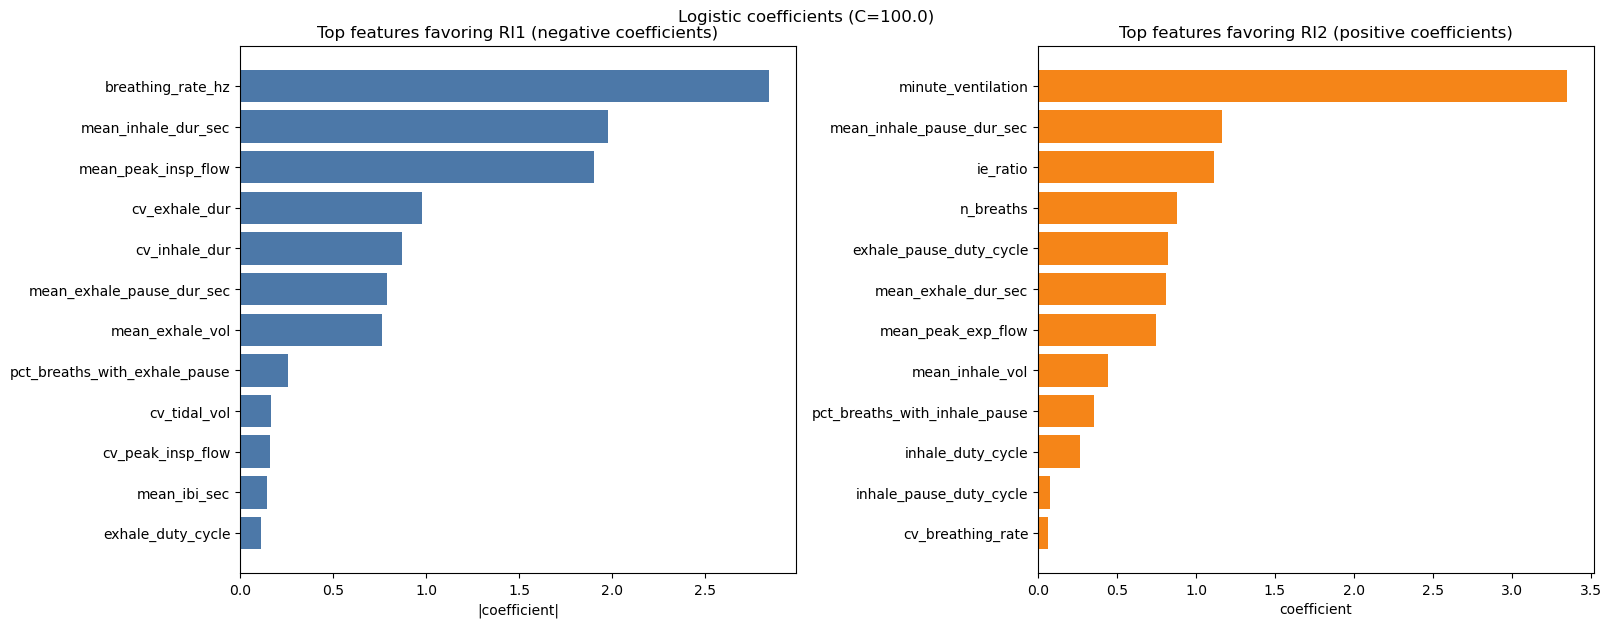

,Model,TrueMouseID,n_windows,balanced_accuracy,macro_f1,flip_balanced_accuracy,flip_macro_f1
7,LogisticRegression,4_8,199,0.919899,0.919352,0.080101,0.077046
3,LogisticRegression,2_4,182,0.877439,0.881610,0.122561,0.112141
5,LogisticRegression,3_6,187,0.817816,0.820051,0.182184,0.172471
0,LogisticRegression,1_1,200,0.815000,0.814958,0.185000,0.184817
4,LogisticRegression,3_5,200,0.785000,0.784995,0.215000,0.214980
6,LogisticRegression,4_7,200,0.775000,0.774045,0.225000,0.221712
2,LogisticRegression,2_3,196,0.731875,0.728329,0.268125,0.252146
1,LogisticRegression,1_2,190,0.673684,0.673540,0.326316,0.326017
23,RandomForest,4_8,199,0.894697,0.894302,0.105303,0.103694
19,RandomForest,2_4,182,0.849756,0.856026,0.150244,0.125723



Flip diagnostic for suspected mouse 3_6:


,Model,TrueMouseID,balanced_accuracy,flip_balanced_accuracy,macro_f1,flip_macro_f1
5,LogisticRegression,3_6,0.817816,0.182184,0.820051,0.172471
13,SVM,3_6,0.784080,0.215920,0.785934,0.201961
21,RandomForest,3_6,0.802816,0.197184,0.804530,0.190198


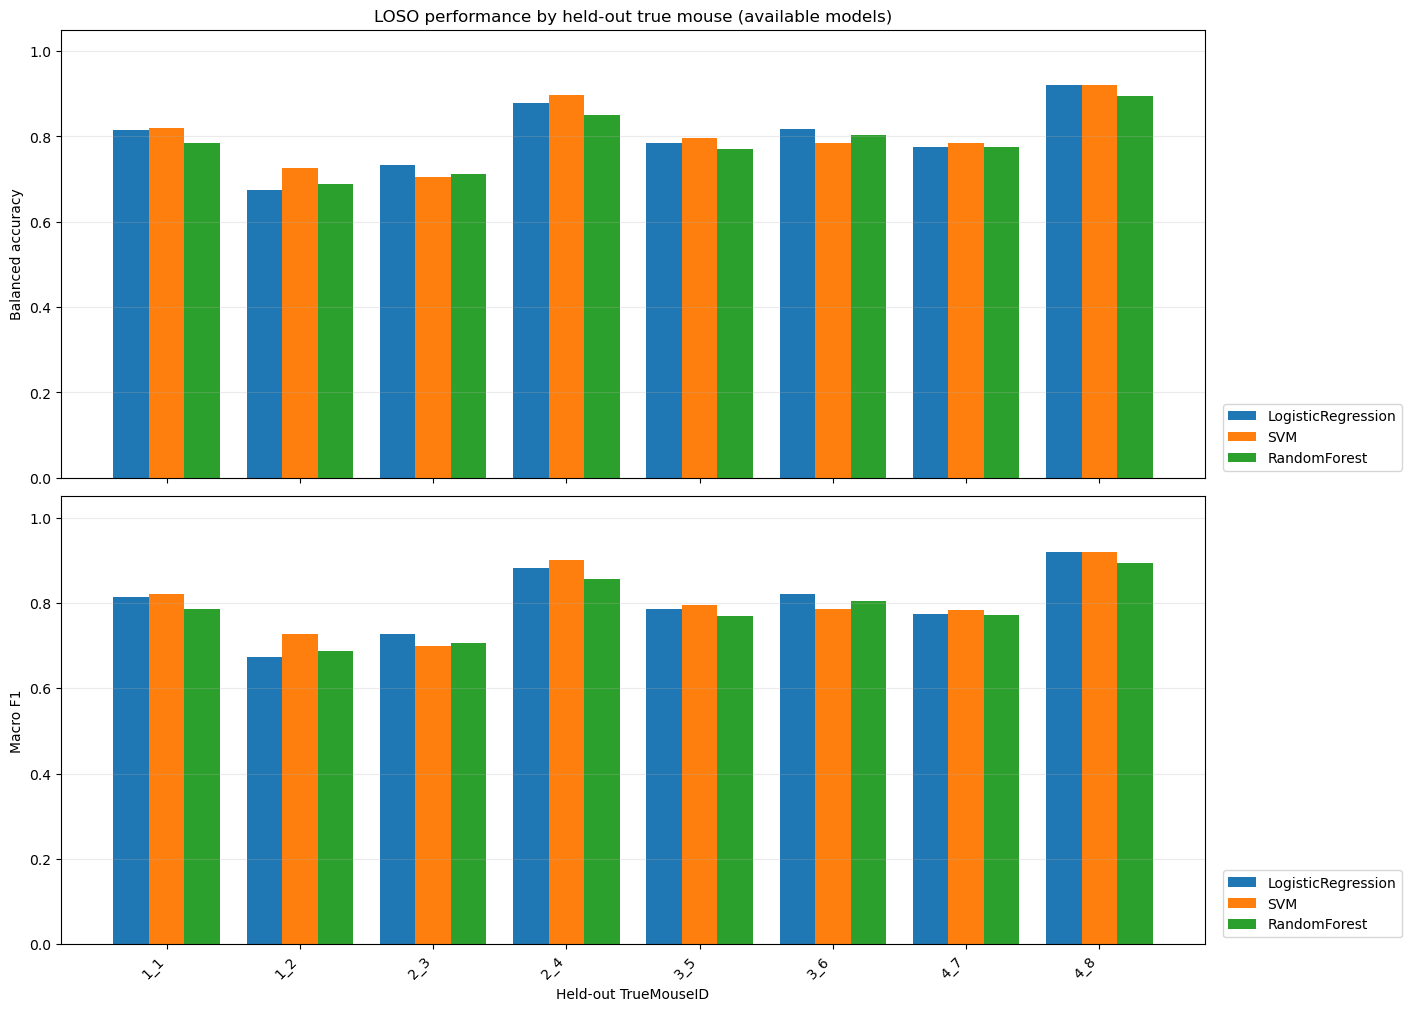

In [125]:
# Coefficient importance (RI1 vs RI2) + per-mouse LOSO performance
from collections import Counter
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.model_selection import LeaveOneGroupOut

if "X" not in globals() or "y" not in globals() or "groups" not in globals():
    raise ValueError("Run the feature/preprocessing cells first so X, y, and groups are available.")

# ---------------------------------------------------------------------
# 1) Build a single logistic model for coefficient interpretation
#    Use most common best C from nested search when available.
# ---------------------------------------------------------------------
def _best_c_from_nested(default_c=1.0):
    if "nested_results" not in globals() or "LogisticRegression" not in nested_results:
        return default_c
    rows = nested_results["LogisticRegression"].get("best_params_per_mouse", [])
    c_vals = []
    for r in rows:
        bp = r.get("best_params", {})
        if "model__C" in bp:
            c_vals.append(bp["model__C"])
    if not c_vals:
        return default_c
    return Counter(c_vals).most_common(1)[0][0]

best_c = _best_c_from_nested(default_c=1.0)
coef_model = Pipeline([
    ("preprocess", preprocess_numeric),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            C=best_c,
            random_state=42,
        ),
    ),
])
coef_model.fit(X, y)

lr = coef_model.named_steps["model"]
if lr.coef_.shape[0] != 1:
    raise ValueError("This plotting cell expects binary logistic regression.")

coef = pd.Series(lr.coef_[0], index=X.columns)
class0, class1 = lr.classes_[0], lr.classes_[1]

# Positive weights push toward class1; negative push toward class0.
top_n = 12
ri2_top = coef.sort_values(ascending=False).head(top_n)
ri1_top = coef.sort_values(ascending=True).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axes[0].barh(ri1_top.index[::-1], np.abs(ri1_top.values[::-1]), color="#4C78A8")
axes[0].set_title(f"Top features favoring {class0} (negative coefficients)")
axes[0].set_xlabel("|coefficient|")

axes[1].barh(ri2_top.index[::-1], ri2_top.values[::-1], color="#F58518")
axes[1].set_title(f"Top features favoring {class1} (positive coefficients)")
axes[1].set_xlabel("coefficient")

plt.suptitle(f"Logistic coefficients (C={best_c})", y=1.02)
plt.show()

# ---------------------------------------------------------------------
# 2) Per-mouse performance from nested_results (no extra long reruns)
# ---------------------------------------------------------------------
if "nested_results" in globals() and len(nested_results):
    per_model_rows = []
    for model_name, vals in nested_results.items():
        for r in vals.get("best_params_per_mouse", []):
            # New schema (preferred): test metrics saved in nested loop.
            if "test_balanced_accuracy" in r and "test_macro_f1" in r:
                per_model_rows.append(
                    {
                        "Model": model_name,
                        "TrueMouseID": r.get("held_out_mouse"),
                        "n_windows": r.get("n_test_windows", np.nan),
                        "balanced_accuracy": r["test_balanced_accuracy"],
                        "macro_f1": r["test_macro_f1"],
                        "flip_balanced_accuracy": r.get("flip_balanced_accuracy", np.nan),
                        "flip_macro_f1": r.get("flip_macro_f1", np.nan),
                    }
                )

    if len(per_model_rows):
        per_mouse_perf = pd.DataFrame(per_model_rows)
        display(per_mouse_perf.sort_values(["Model", "balanced_accuracy"], ascending=[True, False]))

        # Quick diagnostic for your hypothesis: if flip >> original, labels may be inverted for that mouse.
        suspect_mouse = "3_6"
        suspect_rows = per_mouse_perf[per_mouse_perf["TrueMouseID"].astype(str) == suspect_mouse]
        if len(suspect_rows):
            print(f"\nFlip diagnostic for suspected mouse {suspect_mouse}:")
            display(
                suspect_rows[[
                    "Model",
                    "TrueMouseID",
                    "balanced_accuracy",
                    "flip_balanced_accuracy",
                    "macro_f1",
                    "flip_macro_f1",
                ]]
            )

        model_order = list(per_mouse_perf["Model"].unique())
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

        x = np.arange(len(per_mouse_perf["TrueMouseID"].unique()))
        width = 0.8 / max(1, len(model_order))
        mouse_order = sorted(per_mouse_perf["TrueMouseID"].unique())

        for i, m in enumerate(model_order):
            d = (
                per_mouse_perf[per_mouse_perf["Model"] == m]
                .set_index("TrueMouseID")
                .reindex(mouse_order)
            )
            xpos = x - 0.4 + (i + 0.5) * width
            axes[0].bar(xpos, d["balanced_accuracy"].values, width=width, label=m)
            axes[1].bar(xpos, d["macro_f1"].values, width=width, label=m)

        axes[0].set_ylabel("Balanced accuracy")
        axes[0].set_ylim(0, 1.05)
        axes[0].set_title("LOSO performance by held-out true mouse (available models)")

        axes[1].set_ylabel("Macro F1")
        axes[1].set_ylim(0, 1.05)
        axes[1].set_xlabel("Held-out TrueMouseID")

        axes[1].set_xticks(x)
        axes[1].set_xticklabels(mouse_order, rotation=45, ha="right")

        for ax in axes:
            ax.grid(axis="y", alpha=0.25)
            ax.legend(loc="lower left", bbox_to_anchor=(1.01, 0.0))

        plt.show()
    else:
        print("No per-mouse test metrics found in nested_results; run the updated nested-search cell first.")
else:
    print("nested_results not available yet; run nested-search cell first.")
